✅  Imagen guardada como 'opencv_colormaps.png'


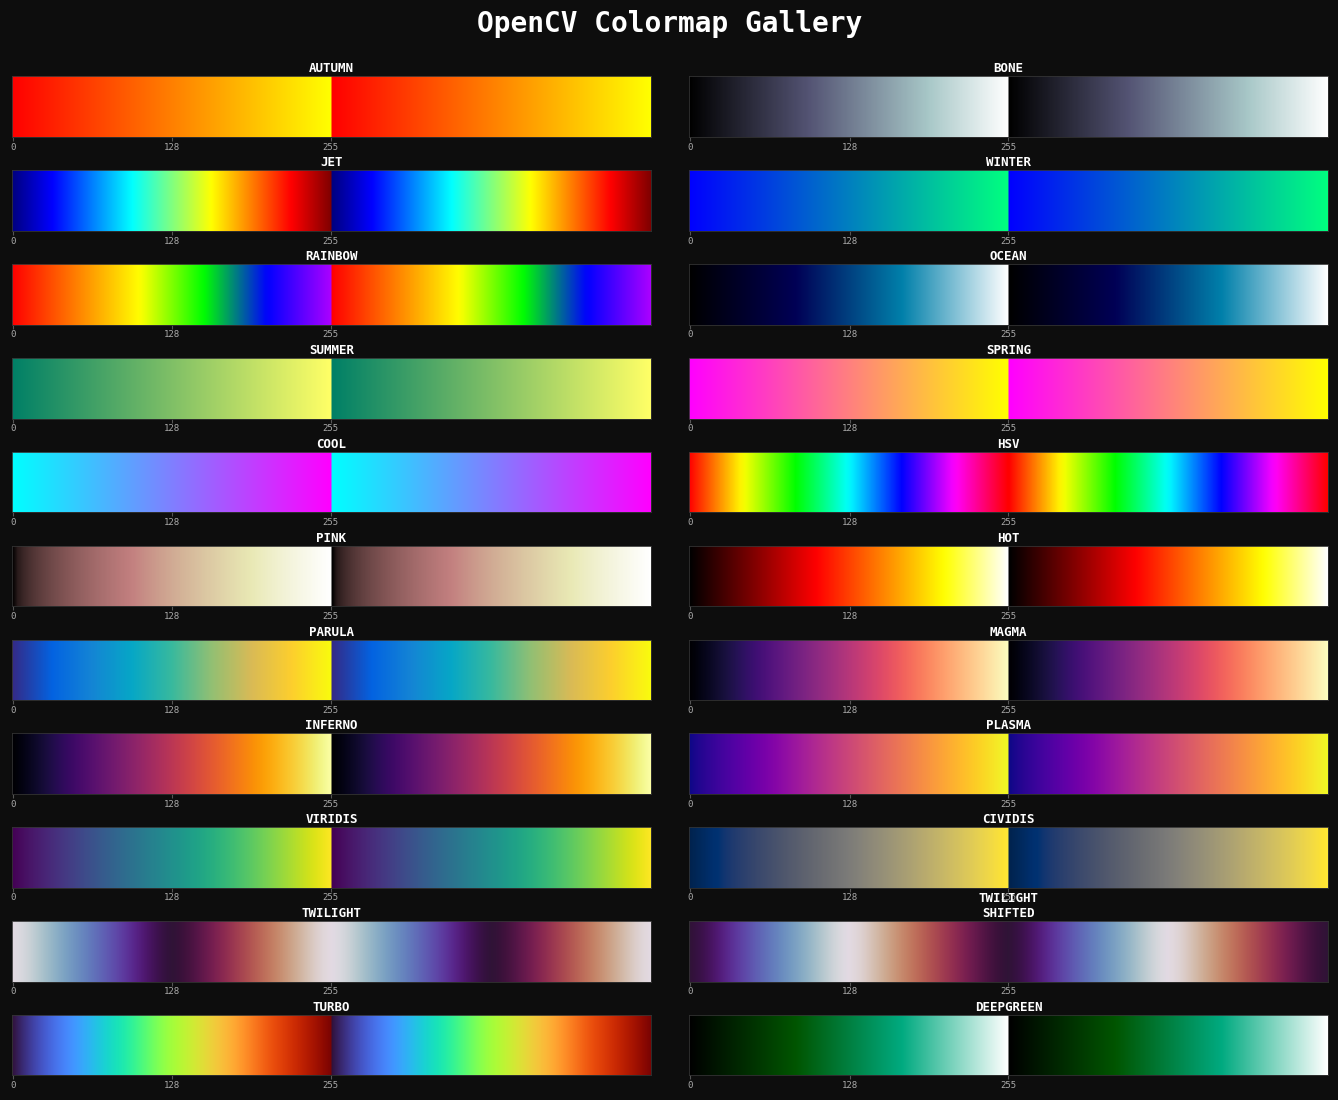

In [1]:
"""
Visualizador de paletas de colores de OpenCV
Stack: cv2 · numpy · matplotlib
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Diccionario con todos los colormaps de OpenCV ──────────────────────────────
COLORMAPS = {
    "AUTUMN":   cv2.COLORMAP_AUTUMN,
    "BONE":     cv2.COLORMAP_BONE,
    "JET":      cv2.COLORMAP_JET,
    "WINTER":   cv2.COLORMAP_WINTER,
    "RAINBOW":  cv2.COLORMAP_RAINBOW,
    "OCEAN":    cv2.COLORMAP_OCEAN,
    "SUMMER":   cv2.COLORMAP_SUMMER,
    "SPRING":   cv2.COLORMAP_SPRING,
    "COOL":     cv2.COLORMAP_COOL,
    "HSV":      cv2.COLORMAP_HSV,
    "PINK":     cv2.COLORMAP_PINK,
    "HOT":      cv2.COLORMAP_HOT,
    "PARULA":   cv2.COLORMAP_PARULA,
    "MAGMA":    cv2.COLORMAP_MAGMA,
    "INFERNO":  cv2.COLORMAP_INFERNO,
    "PLASMA":   cv2.COLORMAP_PLASMA,
    "VIRIDIS":  cv2.COLORMAP_VIRIDIS,
    "CIVIDIS":  cv2.COLORMAP_CIVIDIS,
    "TWILIGHT": cv2.COLORMAP_TWILIGHT,
    "TWILIGHT\nSHIFTED": cv2.COLORMAP_TWILIGHT_SHIFTED,
    "TURBO":    cv2.COLORMAP_TURBO,
    "DEEPGREEN":cv2.COLORMAP_DEEPGREEN,
}

n_maps   = len(COLORMAPS)
bar_h    = 40    # altura en píxeles de cada barra de color
bar_w    = 512   # ancho  en píxeles de cada barra de color

# ── Construir las barras con cv2.applyColorMap ─────────────────────────────────
# Gradiente base: valores 0-255 en horizontal
gradient = np.tile(np.arange(256, dtype=np.uint8), (bar_h, 2)).astype(np.uint8)
# tile para alcanzar bar_w (512 = 256 * 2)

bars_rgb: list[np.ndarray] = []

for name, cmap_id in COLORMAPS.items():
    # cv2 devuelve BGR → convertir a RGB para matplotlib
    colored_bgr = cv2.applyColorMap(gradient, cmap_id)      # (bar_h, bar_w, 3) BGR
    colored_rgb = cv2.cvtColor(colored_bgr, cv2.COLOR_BGR2RGB)
    bars_rgb.append((name, colored_rgb))

# ── Componer figura única con matplotlib ───────────────────────────────────────
cols        = 2                             # columnas de paletas por fila
rows        = (n_maps + cols - 1) // cols   # filas necesarias
fig_w       = 14
fig_h       = rows * 0.9 + 1.2             # altura proporcional

fig = plt.figure(figsize=(fig_w, fig_h), facecolor="#0d0d0d")
fig.suptitle(
    "OpenCV Colormap Gallery",
    fontsize=20, fontweight="bold",
    color="white", y=0.98,
    fontfamily="monospace",
)

gs = gridspec.GridSpec(
    rows, cols,
    figure=fig,
    hspace=0.55, wspace=0.06,
    left=0.03, right=0.97,
    top=0.92, bottom=0.02,
)

# ── FOR principal: un subplot por colormap ─────────────────────────────────────
for idx, (name, bar) in enumerate(bars_rgb):
    row, col = divmod(idx, cols)
    ax = fig.add_subplot(gs[row, col])

    ax.imshow(bar, aspect="auto")

    # Etiqueta del nombre sobre la barra
    ax.set_title(
        name,
        fontsize=9, fontweight="bold",
        color="white", pad=3,
        fontfamily="monospace",
    )

    # Marcas de valor en el eje X (0 · 128 · 255)
    ax.set_xticks([0, 128, 255])
    ax.set_xticklabels(["0", "128", "255"],
                       fontsize=6.5, color="#aaaaaa", fontfamily="monospace")
    ax.tick_params(axis="x", length=3, color="#555555", pad=1)

    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor("#333333")
        spine.set_linewidth(0.6)

plt.savefig(
    "opencv_colormaps.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)
print("✅  Imagen guardada como 'opencv_colormaps.png'")
plt.show()